In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/spaceship-titanic/sample_submission.csv
/kaggle/input/competitions/spaceship-titanic/train.csv
/kaggle/input/competitions/spaceship-titanic/test.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df=pd.read_csv('/kaggle/input/competitions/spaceship-titanic/train.csv')

In [5]:
df.shape

(8693, 14)

In [6]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True



## Pandas Profiling

In [7]:

# from ydata_profiling import ProfileReport

# # Create profile report
# profile = ProfileReport(df, title="Pandas Profiling Report")

# profile.to_file("report.html")
# print('File Created succesfully')

In [8]:
# Numerical -> Age,Room Service , Food Court , Shopping Mall ,Spa , VRDeck
# Categorical -> Home Planet , 
# Boolean -> Cryosleep , VIP ,
# Mixing ->Cabin , PassengerId , Destination

## Univarient Analysis

In [9]:
df['Age'].describe()

count    8514.000000
mean       28.827930
std        14.489021
min         0.000000
25%        19.000000
50%        27.000000
75%        38.000000
max        79.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Density'>

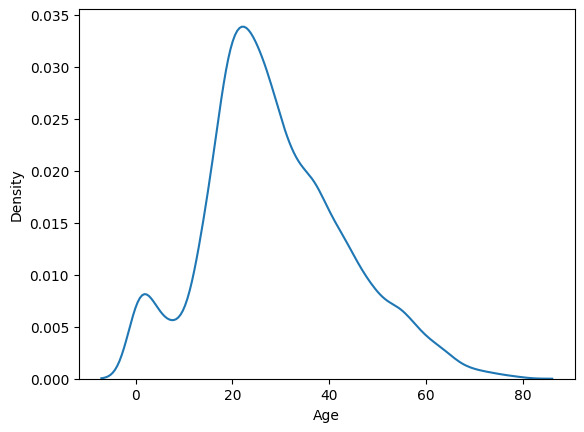

In [10]:
sns.kdeplot(df['Age'])

<Axes: ylabel='Age'>

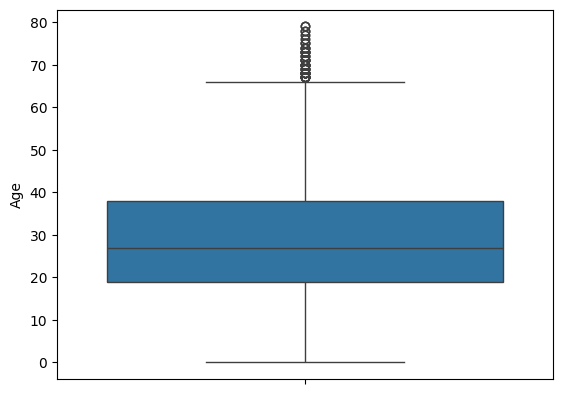

In [11]:
sns.boxplot(df['Age'])

In [12]:
df[df['Age']>70]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
338,0378_03,Europa,False,B/11/S,TRAPPIST-1e,79.0,False,5649.0,235.0,7.0,2579.0,2175.0,Naslon Pirejus,False
416,0453_03,Europa,True,B/14/S,TRAPPIST-1e,74.0,False,0.0,0.0,0.0,0.0,0.0,Wezena Taptiritty,True
615,0642_03,Europa,False,C/25/S,TRAPPIST-1e,79.0,False,0.0,0.0,0.0,2210.0,2.0,Chabik Kiling,False
779,0818_01,Europa,False,B/29/S,TRAPPIST-1e,71.0,True,0.0,0.0,0.0,0.0,0.0,Ksorab Couseced,True
848,0911_02,NaN,False,F/189/P,TRAPPIST-1e,74.0,False,853.0,0.0,543.0,31.0,0.0,Froops Blate,True
917,0984_08,Earth,True,G/150/S,TRAPPIST-1e,71.0,False,0.0,0.0,0.0,0.0,0.0,Alancy Flemaney,True
1157,1222_01,Earth,False,G/183/P,TRAPPIST-1e,75.0,False,0.0,493.0,0.0,131.0,132.0,Evenna Hubert,False
1390,1455_05,Europa,False,B/62/S,55 Cancri e,76.0,False,0.0,2732.0,422.0,16594.0,330.0,Antino Wassird,False
1429,1507_03,Earth,False,G/231/S,TRAPPIST-1e,78.0,False,0.0,0.0,0.0,441.0,4.0,Anny Jeffey,False
1686,1792_01,Mars,False,F/352/P,TRAPPIST-1e,73.0,False,27.0,2.0,71.0,1208.0,0.0,Duckes Brazo,False


In [13]:
df['Age']=df['Age'].fillna(df["Age"].mean)

In [14]:
df['Age'].isnull().sum()

np.int64(0)

## RoomService

In [15]:
df['RoomService'].describe()

count     8512.000000
mean       224.687617
std        666.717663
min          0.000000
25%          0.000000
50%          0.000000
75%         47.000000
max      14327.000000
Name: RoomService, dtype: float64

<Axes: xlabel='RoomService', ylabel='Density'>

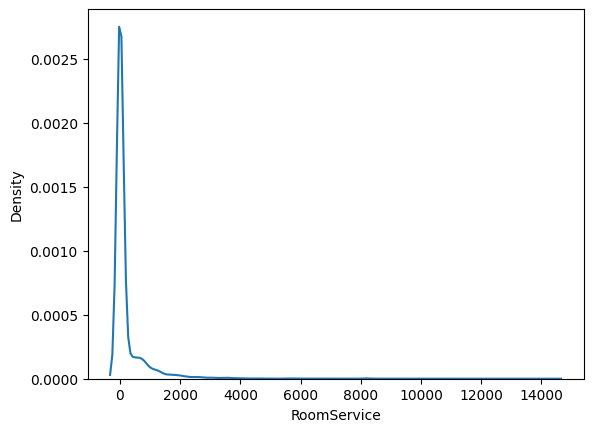

In [16]:
sns.kdeplot(df["RoomService"])

<Axes: ylabel='RoomService'>

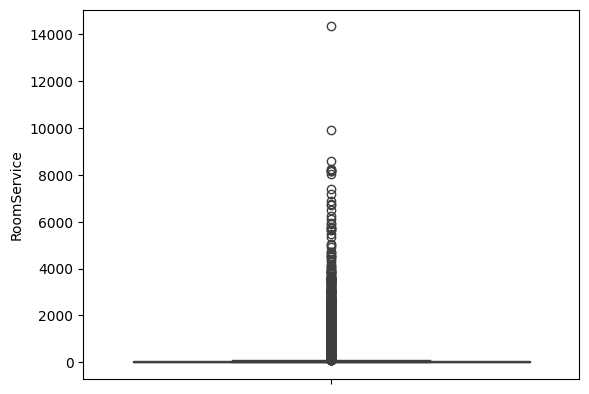

In [17]:
sns.boxplot(df['RoomService'])

In [18]:
df[df["RoomService"]==0]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8687,9275_03,Europa,NaN,A/97/P,TRAPPIST-1e,30.0,False,0.0,3208.0,0.0,2.0,330.0,Atlasym Conable,True
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True


<Axes: ylabel='Density'>

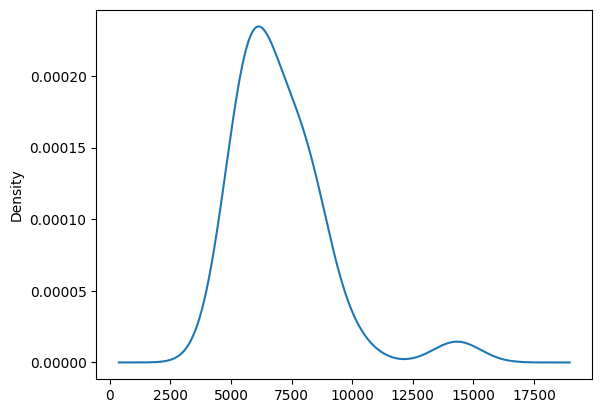

In [19]:
df[(df['RoomService'] > 5000) & (df['Transported'] == False)]['RoomService'].plot(kind='kde')

In [20]:
df['RoomService'].isnull().sum()

np.int64(181)

In [21]:
df['RoomService']=df['RoomService'].fillna(0)

In [22]:
df[df['RoomService'] > 4000]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
75,0082_01,Mars,False,F/16/P,TRAPPIST-1e,42.0,False,7406.0,0.0,0.0,0.0,0.0,Totse Datte,False
140,0160_01,Earth,False,G/22/P,TRAPPIST-1e,22.0,False,4119.0,0.0,0.0,0.0,61.0,Gory Atkinney,False
301,0334_01,Mars,False,F/62/S,TRAPPIST-1e,29.0,False,5715.0,2.0,211.0,1476.0,0.0,Unfly Mushe,False
338,0378_03,Europa,False,B/11/S,TRAPPIST-1e,79.0,False,5649.0,235.0,7.0,2579.0,2175.0,Naslon Pirejus,False
928,0992_04,Europa,False,NaN,55 Cancri e,35.0,True,8030.0,300.0,0.0,0.0,1436.0,Naosa Herpumble,False
930,0992_06,Europa,False,D/35/S,55 Cancri e,37.0,False,4301.0,791.0,0.0,1748.0,91.0,Weidus Kiling,False
1177,1243_02,Europa,False,A/9/P,TRAPPIST-1e,32.0,False,8168.0,69.0,11.0,371.0,0.0,Geno Oderient,False
1459,1542_01,Mars,False,F/299/S,TRAPPIST-1e,13.0,False,7172.0,0.0,157.0,20.0,0.0,Tot Seche,False
1467,1550_02,Europa,False,NaN,55 Cancri e,53.0,True,5022.0,2376.0,0.0,0.0,235.0,Coxaton Supiensive,False
1703,1810_01,Mars,False,F/356/P,TRAPPIST-1e,56.0,False,4694.0,0.0,2661.0,51.0,0.0,Whee Ruité,False


## FoodCourt	

In [23]:
df['FoodCourt'].describe()

count     8510.000000
mean       458.077203
std       1611.489240
min          0.000000
25%          0.000000
50%          0.000000
75%         76.000000
max      29813.000000
Name: FoodCourt, dtype: float64

In [24]:
df['FoodCourt'].isnull().sum()

np.int64(183)

<Axes: xlabel='FoodCourt', ylabel='Density'>

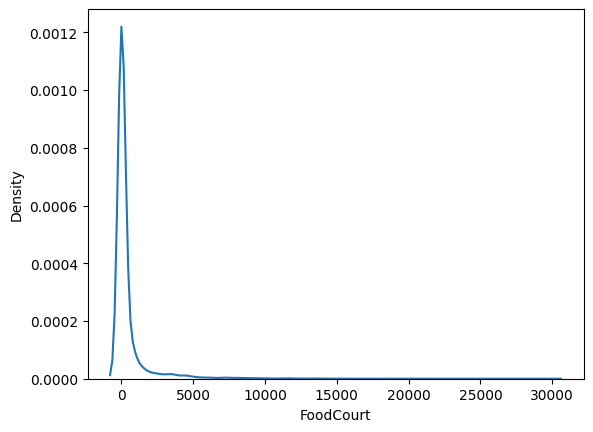

In [25]:
sns.kdeplot(df['FoodCourt'])

<Axes: ylabel='FoodCourt'>

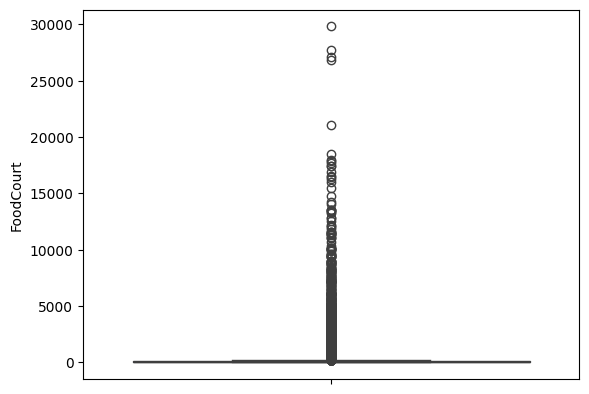

In [26]:
sns.boxplot(df['FoodCourt'])

###### 

<Axes: ylabel='Density'>

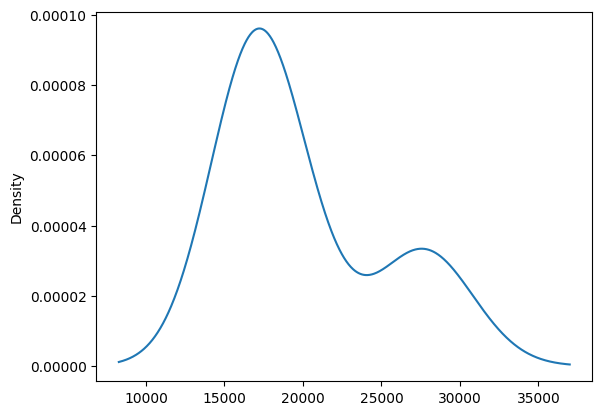

In [27]:
df[(df["FoodCourt"]>15000) & (df['Transported']==True)]['FoodCourt'].plot(kind='kde')
# df[(df['RoomService'] > 3700) & (df['Transported'] == False)]['RoomService']

In [28]:
df[(df["FoodCourt"]>15000) & (df['RoomService']==0)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
474,0510_01,Europa,False,C/16/P,TRAPPIST-1e,59.0,False,0.0,16521.0,0.0,323.0,0.0,Astrark Sinecthex,True
1213,1292_01,Europa,False,B/55/S,55 Cancri e,31.0,True,0.0,27723.0,3.0,202.0,3146.0,Scharab Conale,True
1496,1588_02,Europa,False,E/99/P,55 Cancri e,35.0,False,0.0,17394.0,0.0,724.0,0.0,Hyaduma Fullous,True
1770,1882_01,Europa,NaN,C/71/S,55 Cancri e,18.0,False,0.0,16263.0,72.0,0.0,15.0,Magnon Antcal,True
1842,1969_01,Europa,False,C/75/S,55 Cancri e,27.0,False,0.0,21066.0,0.0,2448.0,2293.0,Unukath Sandul,True
2067,2215_01,Europa,False,A/27/S,55 Cancri e,41.0,True,0.0,29813.0,0.0,1257.0,6.0,Pulchib Quidedbolt,True
3180,3428_02,Europa,False,C/113/P,TRAPPIST-1e,27.0,False,0.0,18481.0,0.0,2.0,3875.0,Terope Cumpting,True
3198,3444_01,Europa,False,B/131/S,55 Cancri e,33.0,False,0.0,27071.0,0.0,15.0,0.0,Ainoxa Scerodbox,True
3428,3699_02,Europa,False,C/123/P,55 Cancri e,25.0,NaN,0.0,17432.0,0.0,241.0,2102.0,Gorab Tronsive,True
4083,4359_02,Europa,False,C/137/P,55 Cancri e,40.0,False,0.0,17687.0,0.0,425.0,155.0,Strali Sebleve,True


In [29]:
df[(df["FoodCourt"]>15000) & (df['Transported']==False)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
7353,7866_01,Europa,False,C/255/P,55 Cancri e,43.0,False,0.0,16856.0,0.0,4344.0,977.0,Tabdhib Heeroling,False


## Shopping Mall

In [30]:
df['ShoppingMall'].describe()

count     8485.000000
mean       173.729169
std        604.696458
min          0.000000
25%          0.000000
50%          0.000000
75%         27.000000
max      23492.000000
Name: ShoppingMall, dtype: float64

<Axes: xlabel='ShoppingMall', ylabel='Density'>

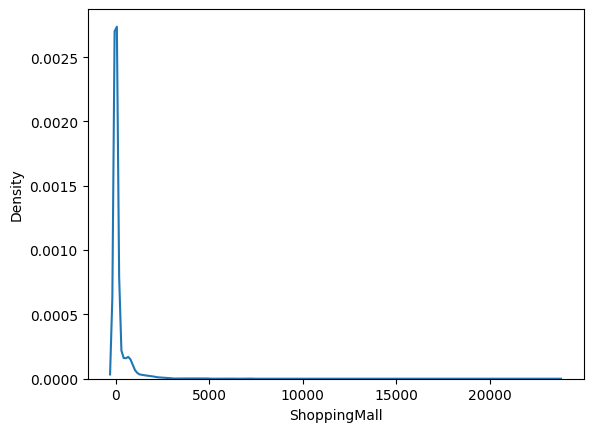

In [31]:
sns.kdeplot(df['ShoppingMall'])

<Axes: ylabel='ShoppingMall'>

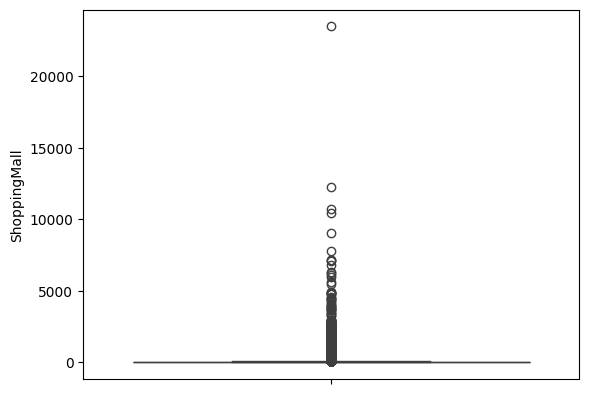

In [32]:
sns.boxplot(df['ShoppingMall'])

In [33]:
df[(df['ShoppingMall']>5000) &(df['Transported']==True)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
375,0412_01,Europa,False,C/11/P,TRAPPIST-1e,60.0,False,0.0,7255.0,5952.0,1537.0,0.0,Baton Quelfly,True
385,0427_01,Europa,False,E/26/P,TRAPPIST-1e,31.0,False,417.0,NaN,7185.0,562.0,792.0,Algor Efulows,True
637,0665_01,NaN,False,F/141/P,TRAPPIST-1e,28.0,False,0.0,0.0,7104.0,0.0,0.0,Cineys Winie,True
1043,1112_01,Europa,False,B/39/P,55 Cancri e,40.0,False,0.0,4076.0,6124.0,58.0,100.0,Elebola Opshaft,True
4621,4925_01,Mars,False,F/936/S,TRAPPIST-1e,23.0,False,197.0,76.0,5635.0,7.0,0.0,Dynx Sfin,True
5137,5488_02,Europa,False,B/186/P,TRAPPIST-1e,15.0,False,0.0,22.0,6805.0,0.0,531.0,Acrabik Hoorherve,True
5673,6027_01,Europa,False,B/232/S,TRAPPIST-1e,36.0,False,0.0,1828.0,9058.0,1.0,2.0,Graviph Coweboded,True
5989,6340_01,Europa,False,C/195/P,TRAPPIST-1e,29.0,False,0.0,584.0,5468.0,7.0,661.0,Gacrab Pressive,True
6223,6583_01,Europa,False,B/254/S,TRAPPIST-1e,13.0,False,0.0,100.0,12253.0,6.0,80.0,Charda Sunlove,True
6453,6814_01,Mars,False,E/451/S,55 Cancri e,36.0,False,1339.0,6.0,7810.0,0.0,0.0,Flark Potte,True


In [34]:
df['ShoppingMall'].isnull().sum()

np.int64(208)

## Spa

In [35]:
df['Spa'].describe()

count     8510.000000
mean       311.138778
std       1136.705535
min          0.000000
25%          0.000000
50%          0.000000
75%         59.000000
max      22408.000000
Name: Spa, dtype: float64

In [36]:
df['Spa'].isnull().sum()

np.int64(183)

<Axes: ylabel='Spa'>

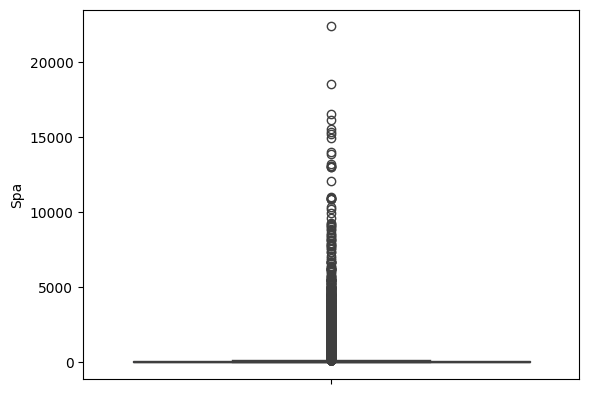

In [37]:
sns.boxplot(df['Spa'])

<Axes: xlabel='Spa', ylabel='Density'>

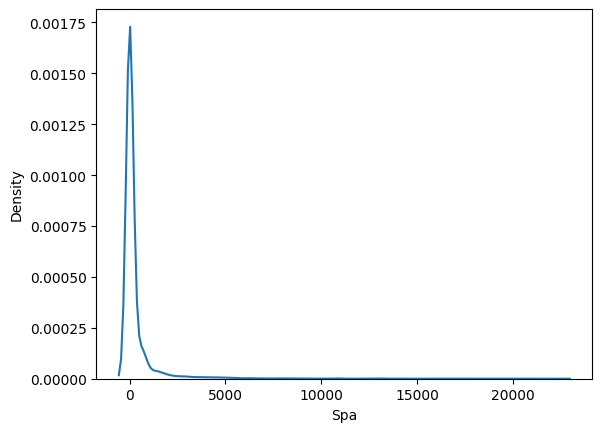

In [38]:
sns.kdeplot(df['Spa'])

In [39]:
df[(df['Spa']>3000) & (df['Transported']==True)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
2091,2237_01,Europa,False,C/83/S,55 Cancri e,28.0,False,0.0,162.0,741.0,3733.0,99.0,Skatik Fushausive,True
3867,4147_01,Europa,False,C/149/S,TRAPPIST-1e,54.0,False,0.0,NaN,0.0,3200.0,0.0,Caphact Lendly,True
4059,4336_04,Europa,False,C/155/S,55 Cancri e,40.0,False,2320.0,0.0,4874.0,3131.0,498.0,Krazet Gloother,True
5340,5709_01,Europa,False,C/215/S,TRAPPIST-1e,33.0,False,0.0,4372.0,0.0,4103.0,0.0,Asellum Amblereld,True


## VRDesk

In [40]:
df['VRDeck'].isnull().sum()

np.int64(188)

In [41]:
df['VRDeck'].describe()

count     8505.000000
mean       304.854791
std       1145.717189
min          0.000000
25%          0.000000
50%          0.000000
75%         46.000000
max      24133.000000
Name: VRDeck, dtype: float64

<Axes: ylabel='VRDeck'>

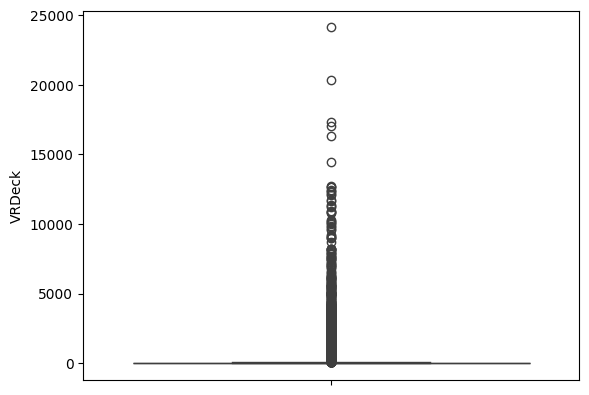

In [42]:
sns.boxplot(df['VRDeck'])

In [43]:
df[(df['VRDeck']>1200) & (df['Transported']==False)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
73,0078_01,Europa,False,C/4/S,TRAPPIST-1e,38.0,False,0.0,5840.0,0.0,321.0,9654.0,Spuri Pokerheed,False
104,0110_02,Europa,NaN,B/5/P,TRAPPIST-1e,40.0,False,0.0,331.0,0.0,0.0,1687.0,Aldeba Bootious,False
113,0119_01,NaN,False,A/0/P,TRAPPIST-1e,39.0,False,0.0,2344.0,0.0,65.0,6898.0,Batan Coning,False
154,0177_01,Europa,False,B/2/S,TRAPPIST-1e,38.0,False,0.0,10346.0,1.0,14970.0,2111.0,Toperon Iniouser,False
193,0216_01,Earth,False,F/40/S,55 Cancri e,21.0,False,0.0,56.0,0.0,0.0,1918.0,Searla Garnes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8613,9194_01,NaN,False,E/603/S,55 Cancri e,53.0,False,0.0,4017.0,0.0,13.0,3147.0,NaN,False
8619,9196_03,Europa,False,C/339/S,TRAPPIST-1e,23.0,False,381.0,794.0,52.0,654.0,1317.0,Chellus Poustive,False
8621,9197_02,Europa,False,C/308/P,NaN,41.0,True,0.0,7964.0,0.0,3238.0,5839.0,Aludram Platch,False
8623,9197_04,Europa,False,C/308/P,55 Cancri e,30.0,False,1569.0,NaN,0.0,NaN,2252.0,Phecca Platch,False


In [44]:
df[(df['ShoppingMall']>5000) & (df['Transported']==True)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
375,0412_01,Europa,False,C/11/P,TRAPPIST-1e,60.0,False,0.0,7255.0,5952.0,1537.0,0.0,Baton Quelfly,True
385,0427_01,Europa,False,E/26/P,TRAPPIST-1e,31.0,False,417.0,NaN,7185.0,562.0,792.0,Algor Efulows,True
637,0665_01,NaN,False,F/141/P,TRAPPIST-1e,28.0,False,0.0,0.0,7104.0,0.0,0.0,Cineys Winie,True
1043,1112_01,Europa,False,B/39/P,55 Cancri e,40.0,False,0.0,4076.0,6124.0,58.0,100.0,Elebola Opshaft,True
4621,4925_01,Mars,False,F/936/S,TRAPPIST-1e,23.0,False,197.0,76.0,5635.0,7.0,0.0,Dynx Sfin,True
5137,5488_02,Europa,False,B/186/P,TRAPPIST-1e,15.0,False,0.0,22.0,6805.0,0.0,531.0,Acrabik Hoorherve,True
5673,6027_01,Europa,False,B/232/S,TRAPPIST-1e,36.0,False,0.0,1828.0,9058.0,1.0,2.0,Graviph Coweboded,True
5989,6340_01,Europa,False,C/195/P,TRAPPIST-1e,29.0,False,0.0,584.0,5468.0,7.0,661.0,Gacrab Pressive,True
6223,6583_01,Europa,False,B/254/S,TRAPPIST-1e,13.0,False,0.0,100.0,12253.0,6.0,80.0,Charda Sunlove,True
6453,6814_01,Mars,False,E/451/S,55 Cancri e,36.0,False,1339.0,6.0,7810.0,0.0,0.0,Flark Potte,True


In [45]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [46]:
df[['Deck','CabinNum','Side']] = df['Cabin'].str.split('/', expand=True)

In [47]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,CabinNum,Side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1,S


In [48]:
df[(df['Deck']=="A") & (df['Transported']==True)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,CabinNum,Side
52,0056_01,Europa,False,A/1/S,TRAPPIST-1e,2.0,False,0.0,0.0,0.0,0.0,0.0,Okulas Tractive,True,A,1,S
53,0056_02,Europa,True,A/1/S,TRAPPIST-1e,38.0,False,0.0,0.0,0.0,0.0,0.0,Instab Tractive,True,A,1,S
54,0056_03,Europa,False,A/1/S,TRAPPIST-1e,27.0,False,279.0,605.0,3374.0,286.0,3.0,Zinoces Tractive,True,A,1,S
114,0119_02,Europa,True,A/0/P,TRAPPIST-1e,13.0,False,0.0,0.0,0.0,0.0,0.0,Kleeiak Coning,True,A,0,P
181,0202_02,Europa,False,A/2/P,55 Cancri e,<bound method Series.mean of 0 39.0\n1 ...,False,0.0,2433.0,NaN,878.0,443.0,Vegas Embleng,True,A,2,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8179,8741_02,Europa,False,A/91/P,55 Cancri e,49.0,False,0.0,3853.0,0.0,245.0,178.0,Grasath Alaring,True,A,91,P
8465,9038_01,Europa,True,A/106/S,55 Cancri e,28.0,False,0.0,0.0,0.0,0.0,0.0,Betenar Listive,True,A,106,S
8518,9085_03,Europa,True,A/95/P,TRAPPIST-1e,57.0,False,0.0,0.0,0.0,0.0,0.0,Atrix Hometerval,True,A,95,P
8685,9275_01,Europa,False,A/97/P,TRAPPIST-1e,0.0,False,0.0,0.0,0.0,0.0,0.0,Polaton Conable,True,A,97,P


In [49]:
df['Destination'].value_counts()

Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64

In [50]:
df[df['Destination']=='TRAPPIST-1e']

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,CabinNum,Side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8685,9275_01,Europa,False,A/97/P,TRAPPIST-1e,0.0,False,0.0,0.0,0.0,0.0,0.0,Polaton Conable,True,A,97,P
8686,9275_02,Europa,False,A/97/P,TRAPPIST-1e,32.0,False,1.0,1146.0,0.0,50.0,34.0,Diram Conable,False,A,97,P
8687,9275_03,Europa,NaN,A/97/P,TRAPPIST-1e,30.0,False,0.0,3208.0,0.0,2.0,330.0,Atlasym Conable,True,A,97,P
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True,G,1500,S


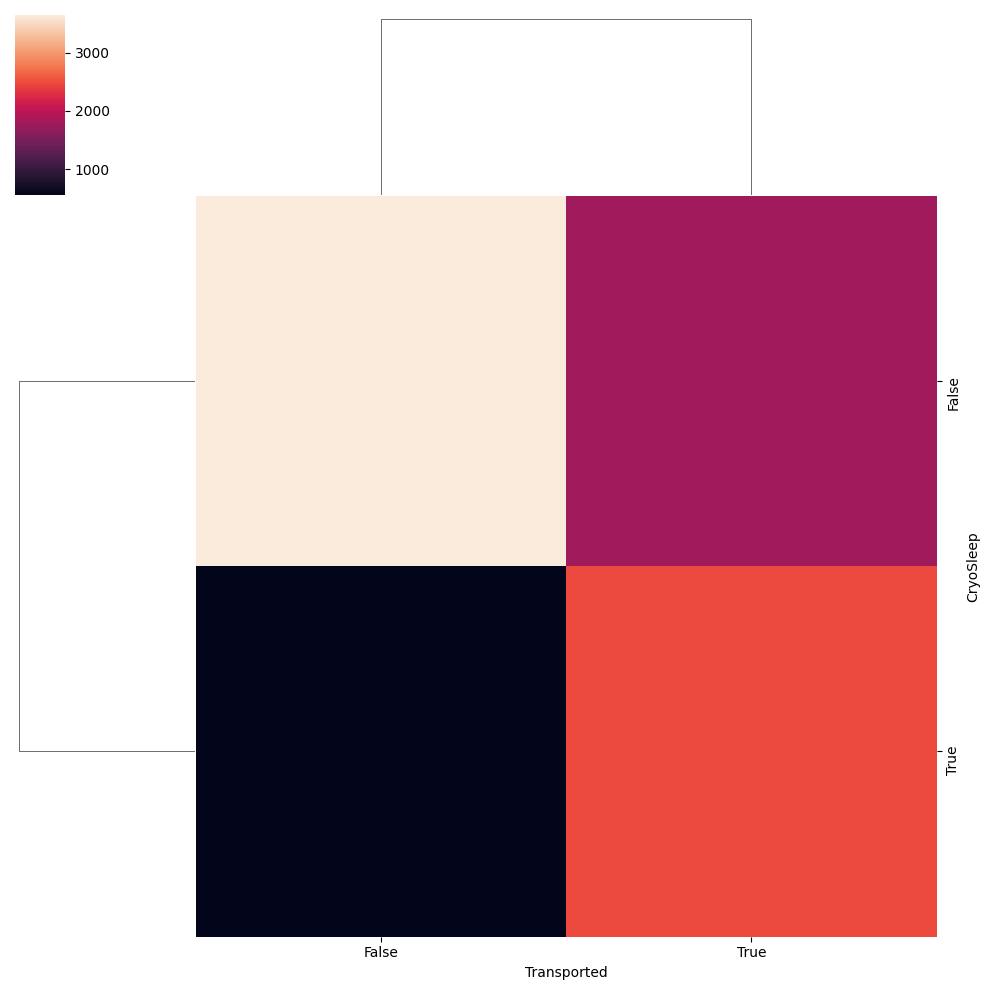

In [51]:
sns.clustermap(pd.crosstab(df['CryoSleep'],df['Transported']))

In [52]:
pd.crosstab(df['CryoSleep'],df['Transported'],normalize='index')*100

Transported,False,True
CryoSleep,,
False,67.107924,32.892076
True,18.241686,81.758314


In [53]:
df['CryoSleep'].isnull().sum()

np.int64(217)

<Axes: xlabel='HomePlanet', ylabel='count'>

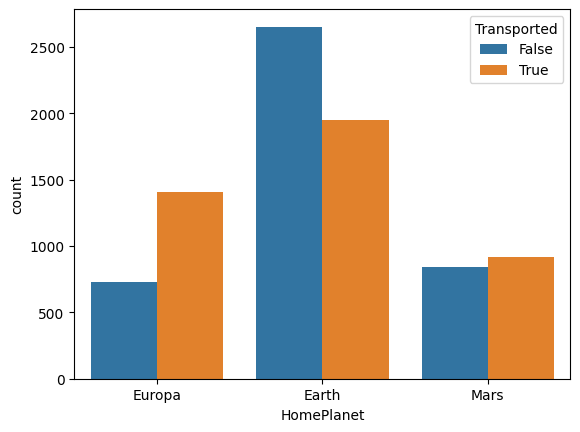

In [54]:
sns.countplot(x='HomePlanet', hue='Transported', data=df)

<Axes: xlabel='Destination', ylabel='count'>

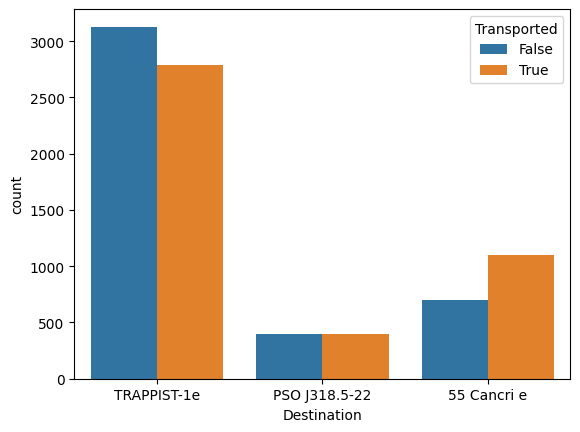

In [55]:
sns.countplot(x='Destination', hue='Transported', data=df)

In [56]:
df['Age'].unique()

array([39.0, 24.0, 58.0, 33.0, 16.0, 44.0, 26.0, 28.0, 35.0, 14.0, 34.0,
       45.0, 32.0, 48.0, 31.0, 27.0, 0.0, 1.0, 49.0, 29.0, 10.0, 7.0,
       21.0, 62.0, 15.0, 43.0, 47.0, 2.0, 20.0, 23.0, 30.0, 17.0, 55.0,
       4.0, 19.0, 56.0, <bound method Series.mean of 0       39.0
                        1       24.0
                        2       58.0
                        3       33.0
                        4       16.0
                                ...
                        8688    41.0
                        8689    18.0
                        8690    26.0
                        8691    32.0
                        8692    44.0
                        Name: Age, Length: 8693, dtype: float64> , 25.0,
       38.0, 36.0, 22.0, 18.0, 42.0, 37.0, 13.0, 8.0, 40.0, 3.0, 54.0,
       9.0, 6.0, 64.0, 67.0, 61.0, 50.0, 41.0, 57.0, 11.0, 52.0, 51.0,
       46.0, 60.0, 63.0, 59.0, 5.0, 79.0, 68.0, 74.0, 12.0, 53.0, 65.0,
       71.0, 75.0, 70.0, 76.0, 78.0, 73.0, 66.0, 69.0, 72.0, 77

In [57]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

<Axes: xlabel='Age', ylabel='Density'>

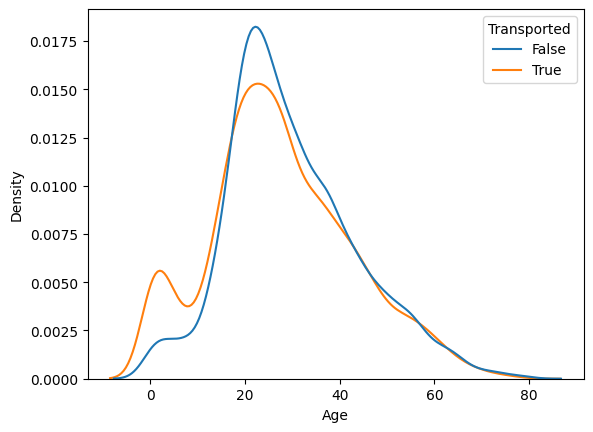

In [58]:
sns.kdeplot(data=df, x='Age', hue='Transported')

<Axes: xlabel='CryoSleep', ylabel='count'>

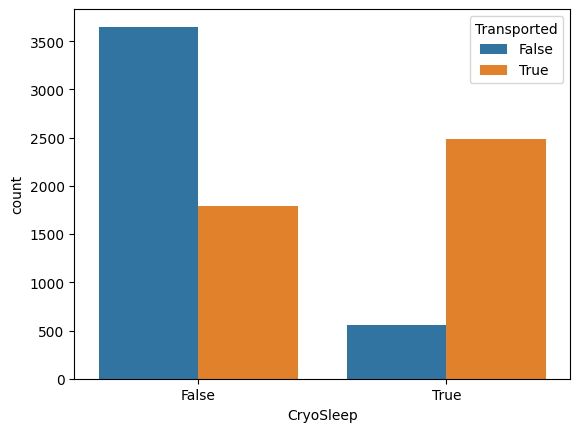

In [59]:
sns.countplot(x='CryoSleep', hue='Transported', data=df)

In [60]:
df.groupby('Transported')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Transported,,,,,,,,
False,4226.0,29.922858,13.699262,0.0,21.0,27.0,38.0,79.0
True,4288.0,27.748834,15.151705,0.0,18.0,26.0,37.0,78.0


<Axes: xlabel='Transported', ylabel='Age'>

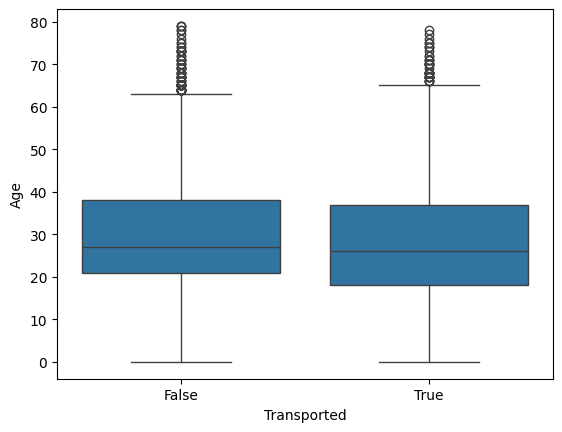

In [61]:
sns.boxplot(x='Transported', y='Age', data=df)

# PassengerId

In [62]:
id=df.groupby('Transported')['PassengerId']

In [63]:
df[['GroupID', 'GroupMember']] = df['PassengerId'].str.split('_', expand=True)

In [64]:
df['GroupID'] = df['GroupID'].astype(int)
df['GroupMember'] = df['GroupMember'].astype(int)

In [65]:
group_size = df.groupby('GroupID').size()

In [66]:
df['GroupSize'] = df.groupby('GroupID')['PassengerId'].transform('count')

In [67]:
df.groupby('GroupID')['Transported'].nunique()

GroupID
1       1
2       1
3       1
4       1
5       1
       ..
9275    2
9276    1
9278    1
9279    1
9280    2
Name: Transported, Length: 6217, dtype: int64

<Axes: xlabel='GroupSize', ylabel='Transported'>

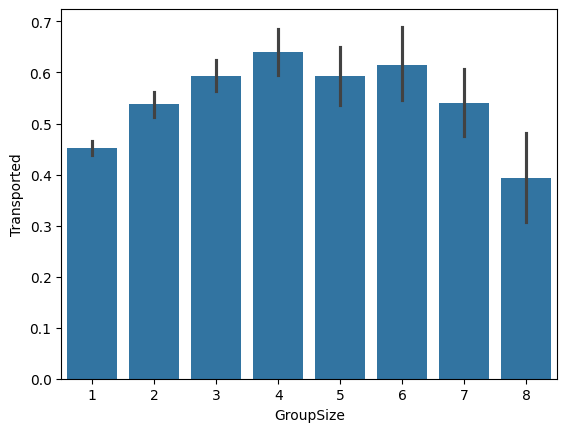

In [68]:
sns.barplot(x='GroupSize', y='Transported', data=df)

In [69]:
df.groupby('GroupMember')['Transported'].mean()

GroupMember
1    0.475953
2    0.558782
3    0.618214
4    0.593074
5    0.546875
6    0.546667
7    0.500000
8    0.461538
Name: Transported, dtype: float64

In [70]:
df['GroupMember'].value_counts().sort_index()

GroupMember
1    6217
2    1412
3     571
4     231
5     128
6      75
7      46
8      13
Name: count, dtype: int64

<Axes: xlabel='GroupMember', ylabel='Transported'>

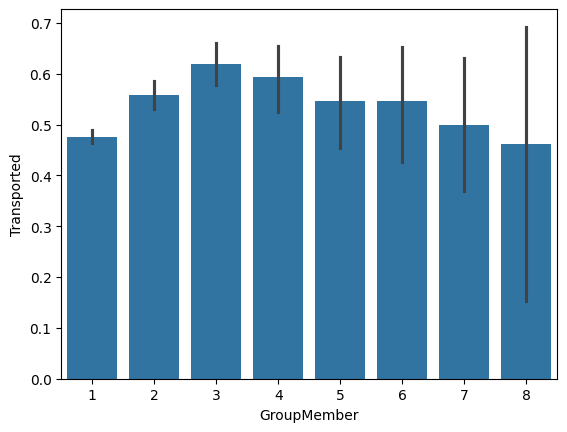

In [71]:
sns.barplot(x='GroupMember', y='Transported', data=df)

In [72]:
df['total_spend']=df['RoomService']+df['FoodCourt']+df['ShoppingMall']+df['VRDeck']+df['Spa']

In [73]:
df.head(2)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,VRDeck,Name,Transported,Deck,CabinNum,Side,GroupID,GroupMember,GroupSize,total_spend
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,0.0,Maham Ofracculy,False,B,0,P,1,1,1,0.0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,44.0,Juanna Vines,True,F,0,S,2,1,1,736.0


In [74]:
df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService       0
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
Deck            199
CabinNum        199
Side            199
GroupID           0
GroupMember       0
GroupSize         0
total_spend     738
dtype: int64

In [75]:
df_copy=df.copy()

In [76]:
df=df_copy[['HomePlanet','CryoSleep','Destination','Age','total_spend','Deck','GroupSize','CabinNum','Side','Transported']]

In [77]:
df_copy.head(1)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,VRDeck,Name,Transported,Deck,CabinNum,Side,GroupID,GroupMember,GroupSize,total_spend
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,0.0,Maham Ofracculy,False,B,0,P,1,1,1,0.0


# **Creating The Pipeline And Building Model**

In [78]:
df.head(1)

,HomePlanet,CryoSleep,Destination,Age,total_spend,Deck,GroupSize,CabinNum,Side,Transported
0,Europa,False,TRAPPIST-1e,39.0,0.0,B,1,0,P,False


In [79]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# target
y = df['Transported']

# features
X = df.drop('Transported', axis=1)

# split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# numeric columns
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler())
])

# categorical columns
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# preprocessing
preprocess = ColumnTransformer([
    ('num', num_pipe, [3,4,6,7]),   # Age, total_spend, GroupSize, CabinNum
    ('cat', cat_pipe, [0,1,2,5,8])  # HomePlanet, CryoSleep, Destination, Deck, Side
])

# final pipeline
pipe_lr = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression())
])


# fit
pipe_lr.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  [3, 4, 6, 7]),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  [0, 1, 2, 5, 8])])),
                ('model', LogisticRegression())])

In [80]:
y_pred=pipe_lr.predict(x_test)

In [81]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7303047728579644


In [83]:
from sklearn.tree import DecisionTreeClassifier
pipe_clf=Pipeline([
    ('preprocess', preprocess),
    ('clf', DecisionTreeClassifier())
])


# fit
pipe_clf.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  [3, 4, 6, 7]),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  [0, 1, 2, 5, 8])])),
                ('clf', DecisionTreeClassifier())])

In [84]:
from sklearn.metrics import accuracy_score

y_pred_dec=pipe_clf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred_dec)
print("Accuracy:", accuracy)

Accuracy: 0.679700977573318


In [85]:
df_copy.head()
df=df_copy[['HomePlanet','CryoSleep','Destination','Age','RoomService','FoodCourt','ShoppingMall','VRDeck','Spa','Deck','Side','GroupSize','Transported']]

# Second try

In [86]:
df.columns

Index(['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'VRDeck', 'Spa', 'Deck', 'Side',
       'GroupSize', 'Transported'],
      dtype='object')

In [161]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler,MinMaxScaler
from sklearn.linear_model import LogisticRegression

# target
y = df['Transported']

# features
X = df.drop('Transported', axis=1)

# split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = [
    'Age',
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'VRDeck',
    'Spa',
    'GroupSize'
]

cat_cols = [
    'HomePlanet',
    'Destination',
    'Deck',
    'Side'
]



# numeric columns
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler())
])

# num_pipe = Pipeline([
#     ('impute', SimpleImputer(strategy='mean')),
#     ('scale', MinMaxScaler())
# ])

# categorical columns
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# preprocessing
preprocess = ColumnTransformer([
    ('num', num_pipe,num_cols),   # Age, total_spend, GroupSize, CabinNum
    ('cat', cat_pipe,cat_cols)  # HomePlanet, CryoSleep, Destination, Deck, Side
])

# final pipeline
pipe_lr = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression())
])


# fit
pipe_lr.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Age', 'RoomService',
                                                   'FoodCourt', 'ShoppingMall',
                                                   'VRDeck', 'Spa',
                                                   'GroupSize']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['HomePlanet', 'Destination',
                                                   'Deck', 'Side'])])),
                ('model', LogisticRegression())])

In [162]:


from sklearn.metrics import accuracy_score

pred=pipe_lr.predict(x_test)

accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)



Accuracy: 0.772857964347326


### Decision Tree

In [98]:
pipe_clf=Pipeline([
    ('preprocess', preprocess),
    ('clf', DecisionTreeClassifier())
])


# fit
pipe_clf.fit(x_train, y_train)

from sklearn.metrics import accuracy_score

y_pred_dec=pipe_clf.predict(x_test)

accuracy = accuracy_score(y_test, y_pred_dec)
print("Accuracy:", accuracy)

Accuracy: 0.7050028752156412


In [99]:
LogisticRegression(class_weight='balanced')

LogisticRegression(class_weight='balanced')

In [100]:
df['Transported'].value_counts(normalize=True)

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64

# Checking The Distribution of the data

In [155]:
from sklearn.preprocessing import FunctionTransformer
trf=FunctionTransformer(func=np.log1p)

In [126]:
x_train.head(2)

,HomePlanet,CryoSleep,Destination,Age,RoomService,FoodCourt,ShoppingMall,VRDeck,Spa,Deck,Side,GroupSize
2333,Earth,False,TRAPPIST-1e,28.0,0.0,55.0,0.0,0.0,656.0,NaN,NaN,1
2589,Earth,False,TRAPPIST-1e,17.0,0.0,1195.0,31.0,0.0,0.0,F,P,3


In [118]:
import matplotlib.pyplot as plt
import scipy.stats as stats

/tmp/ipykernel_57/2107994196.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


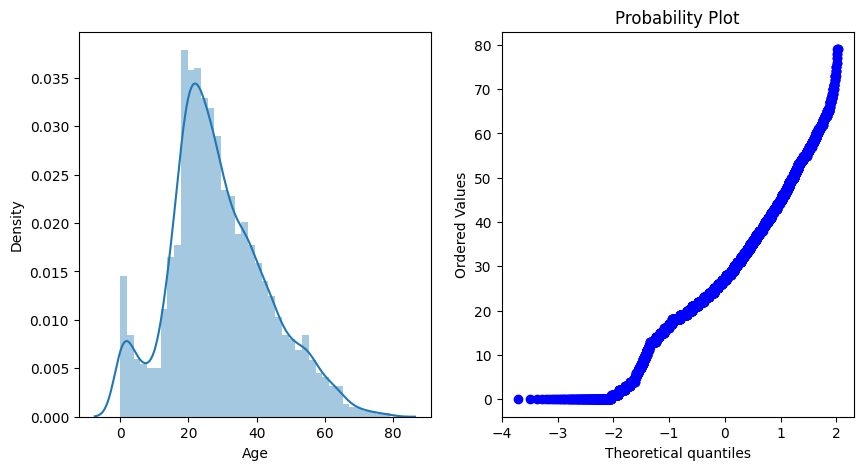

In [119]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.distplot(x_train['Age'])

plt.subplot(1,2,2)
stats.probplot(x_train['Age'], dist="norm",plot=plt)
plt.show()

In [120]:
df['Age'].isnull().sum()

np.int64(179)

((array([-3.71441201, -3.48377757, -3.35689417, ...,  3.35689417,
          3.48377757,  3.71441201]),
  array([ 0.,  0.,  0., ..., 79., 79., 79.])),
 (np.float64(14.306427736811521),
  np.float64(28.828092859241846),
  np.float64(0.9898827181022106)))

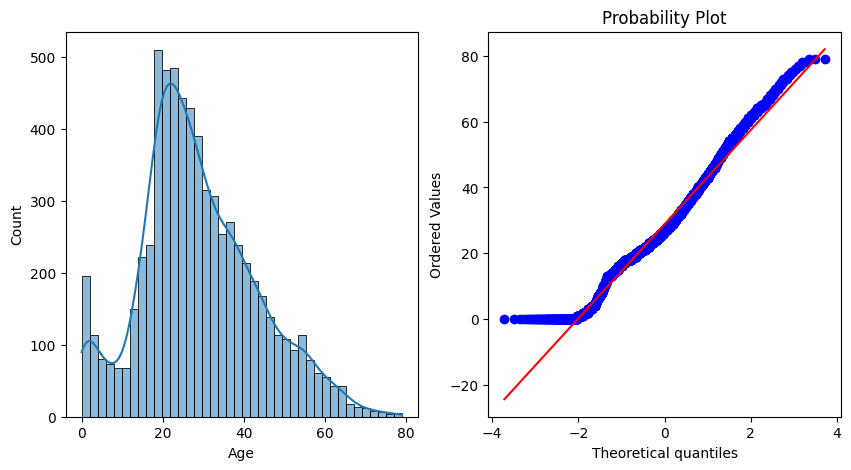

In [122]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(x_train['Age'].dropna(), kde=True)

plt.subplot(1,2,2)
stats.probplot(x_train['Age'].dropna(), dist="norm", plot=plt)

In [168]:
x_train['Age'].skew()

np.float64(0.4311396884924085)

In [167]:
x_train['Age_log'] = trf.fit_transform(x_train[['RoomService']])
x_test['RoomService'] = trf.transform(x_test[['RoomService']])

In [153]:
x_train['RoomService'].skew()

np.float64(0.7306949497871342)

/tmp/ipykernel_57/1797116351.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['RoomService'])


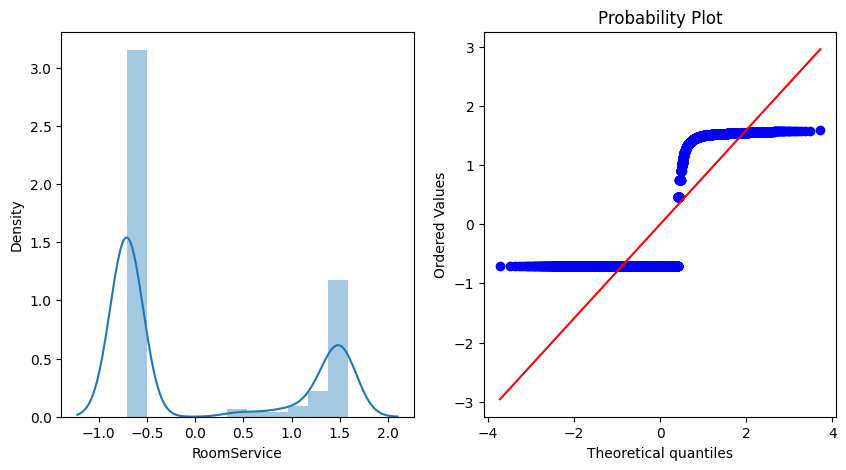

In [154]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.distplot(x_train['RoomService'])

plt.subplot(1,2,2)
stats.probplot(x_train['RoomService'], dist="norm",plot=plt)
plt.show()

In [129]:
x_train['FoodCourt'].skew()

np.float64(6.743002807676836)

In [130]:
x_train['ShoppingMall'].skew()

np.float64(13.0223229874294)